# Построение агентной системы на Python

Данная работа посвящена построению агентных систем на LangChain и LangGraph.

Данная работа выполнена студентом ИАД-4 Коноваловым Матвеем и опирается на семинарские ноутбуки.

## В чём разница между LangChain и LangGraph

| Характеристика | LangChain Agents | LangGraph Agents |
|----------------|-----------------|-----------------|
| Кто управляет логикой | Модель (LLM) | Разработчик |
| Гибкость | Ограничена | Абсолютная |
| Сложность | Простые / средние задачи | Сложные воркфлоу |
| Предсказуемость | Низкая | Высокая |
| Память | Минимальная | Любая, структурированная |
| Подходит для продакшена | Иногда | Да |

---

## Вывод

- **LangChain Agents** — быстрый способ собрать помощника: подключаем инструменты, выбираем тип агента, LLM сама решает, что делать.
- **LangGraph Agents** — контроль над каждым шагом: вы строите граф действий, LLM участвует только в отдельных узлах, что делает систему предсказуемой и надёжной.

**Итоговое правило:**
LangChain = “готовые блоки, которые магически вызывают инструменты”
LangGraph = “строим агента сами, LLM помогает на узлах, а логика полностью под нашим контролем”

## Инициализация LLM
LLM это неотъемлемая часть агентных систем, центральный мозг, вызывающий конкретные инструменты или выполняющий работу с текстом, так что без неё мы в этой работе не обойдемся.

Выбор модели проводился на основании [ранкинга LLM в категории Academia на OpenRouter](https://openrouter.ai/rankings?category=academia#categories) (поскольку обе агентных системы связаны с наукой)

In [85]:
!pip install -qU langchain==0.3.25 langchain-openai==0.3.22 langchain-experimental==0.3.4 numexpr==2.11.0


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [86]:
from langchain_openai import ChatOpenAI
from constants import OPENROUTER_API_KEY

llm = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    temperature=0,
)

## ReAct-агент на LangChain

Было бы круто что-то придумать с md-подписями для клеток, и мб с написанием md-саммари (или хотя бы выводов).

И раз он многофункциональный, то можно ещё анализ кода на соответствие поставленной задаче закинуть.

## Агент на LangGraph
Агент должен обращаться по API, обрабатывать ответ LLM-кой и выдавать в ответе, причем должна решаться полезная для меня задача.

В ходе написания кода для исследований меня часто посещает вопрос "а точно ли то, чем я сейчас занимаюсь, не рассматривалось кем-то в статье?".

Поэтому мой агент будет читать мой код, искать релевантные статьи через API arXiv и саммаризировать для меня, какие вопросы полностью затрагивались, что упоминалось частично, а что представляет научную новизну.

В будущем планируется отвязать агента от кода, чтобы была опция просто у него спрашивать, какие статьи на интересующую меня тему существуют. Чистая LLM-ка, что

In [87]:
!pip install -q langgraph==0.2.76 arxiv charset_normalizer


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [88]:
from typing import TypedDict, List, Dict, Any, Optional, Tuple
import json
import textwrap
import arxiv
from langgraph.graph import START, END, StateGraph
import os
import re
import io
import tarfile
import posixpath
import sqlite3
import hashlib
import requests
import fitz  # PyMuPDF
from datetime import datetime

In [89]:
class AgentState(TypedDict, total=False):
    code: str
    code_summary: str
    extracted_signals: Dict[str, Any]
    algorithmic_structure: Dict[str, Any]
    queries: List[str]
    papers: List[Dict[str, str]]
    paper_algorithms: List[Dict[str, Any]]
    paper_matches: List[Dict[str, Any]]
    final_summary: str

In [90]:
VERBOSE = True
TOP_PAPERS_FOR_RELEVANCE_FILTER = 10
TOP_PAPERS_FOR_LLM_ALGO_EXTRACTION = 3
TOP_PAPERS_FOR_MATCHING = 10
TOP_PAPERS_FOR_DEEP_MATCHING = 6
ALGO_MATCH_SCORE_THRESHOLD = 0.45
ALGORITHM_DB_PATH = os.path.abspath("paper_algorithms_cache.sqlite3")

### Шаг 1. Извлечение сигналов из кода

Здесь LLM-ка, подобно backbone, извлекающему признаки с картинки, извлекает сигналы из кода, по которым дальше будет происходить поиск релевантных статей.

In [91]:
def clean_llm_json_text(text: str) -> str:
    cleaned = (text or "").strip()
    if cleaned.startswith("```json"):
        cleaned = cleaned[len("```json"):].strip()
    if cleaned.startswith("```"):
        cleaned = cleaned[len("```"):].strip()
    if cleaned.endswith("```"):
        cleaned = cleaned[:-3].strip()
    return cleaned


def parse_llm_json(text: str, fallback: Dict[str, Any]) -> Dict[str, Any]:
    cleaned = clean_llm_json_text(text)
    try:
        return json.loads(cleaned)
    except Exception:
        return fallback

In [92]:
def summarize_code(state: AgentState):
    prompt = f"""
Ты анализируешь код исследовательского проекта и готовишь его описание для поиска научных статей.

Нужно вернуть JSON-объект со следующими полями:
- task: краткое название задачи;
- method_kind: тип метода или эксперимента;
- keywords: список ключевых терминов из кода;
- concepts: список более общих исследовательских концептов;
- method_markers: список используемых технических методов и механизмов;
- search_hints: 3-6 коротких поисковых фраз для arXiv.

Вот несколько примеров method_markers (они не обязательно представлены и ты можешь использовать пример не из списка):
- важность через градиент выхода по промежуточному слою;
- feature-level objective;
- интегрирование по пути от baseline к входу;
- итеративная атака с проекцией в L_inf-шар;
- momentum update;
- hook на промежуточный слой;
- сравнение важных и атакованных фич;
- корреляционный или иной анализ связи важности и атаки.

Ответ верни строго в формате JSON без пояснений.

Код:
{state['code']}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("summarize_code raw result:\n", result)

    extracted_signals = parse_llm_json(
        result,
        {
            "task": "unknown",
            "method_kind": "unknown",
            "keywords": [],
            "concepts": [],
            "method_markers": [],
            "search_hints": []
        },
    )

    code_summary = textwrap.dedent(
        f"""
        Task: {extracted_signals.get('task', 'unknown')}
        Method kind: {extracted_signals.get('method_kind', 'unknown')}
        Keywords: {', '.join(extracted_signals.get('keywords', []))}
        Concepts: {', '.join(extracted_signals.get('concepts', []))}
        Method markers: {', '.join(extracted_signals.get('method_markers', []))}
        """
    ).strip()

    if VERBOSE:
        print("Parsed extracted_signals:", extracted_signals)

    return {
        "extracted_signals": extracted_signals,
        "code_summary": code_summary,
    }

### Шаг 2. Извлечение алгоритмической структуры и исследовательского вопроса

Одних общих сигналов недостаточно: для точного поиска статей нужно отдельно извлечь алгоритмический скелет кода. На этом шаге LLM формирует более строгую структуру: основной алгоритм, исследовательский вопрос, используемые методы, характерные шаги процедуры и ключевые фрагменты кода, которые потом пойдут в финальное сопоставление со статьями.

In [93]:
def extract_algorithmic_structure(state: AgentState):
    prompt = f"""
Ты анализируешь код исследовательского проекта. Тебе нужно извлечь не общую тему, а алгоритмическую структуру и исследовательский вопрос.

Верни строго JSON-объект со следующими полями:
- research_question: главный исследовательский вопрос или проверяемая гипотеза;
- algorithm_type: краткий тип алгоритма;
- algorithm_signature: список из 4-8 коротких шагов, описывающих основную процедуру;
- methods_used: список используемых методов и механизмов;
- implementation_markers: список важных технических деталей реализации;
- key_code_spans: список из 3-6 коротких фрагментов кода или псевдокода, которые лучше всего описывают основной алгоритм.

Важно:
- methods_used должен явно выделять используемые методы, например: gradient of class score w.r.t. intermediate features, path integration, feature attribution, feature-level attack objective, momentum iterative update, Linf projection, hook-based feature extraction, comparison of important vs attacked features, attribution/perturbation alignment analysis;
- algorithm_signature должен описывать именно ход алгоритма, а не просто перечислять ключевые слова;
- key_code_spans должны быть короткими, но содержательными и буквально опираться на код.

Ответ верни строго в формате JSON без пояснений.

Код:
{state['code']}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("extract_algorithmic_structure raw result:\n", result)

    algorithmic_structure = parse_llm_json(
        result,
        {
            "research_question": "unknown",
            "algorithm_type": "unknown",
            "algorithm_signature": [],
            "methods_used": [],
            "implementation_markers": [],
            "key_code_spans": []
        }
    )

    if VERBOSE:
        print("Parsed algorithmic_structure:", algorithmic_structure)

    return {"algorithmic_structure": algorithmic_structure}

### Шаг 3. Построение нескольких поисковых запросов

Чтобы повысить полноту поиска, агент строит не один запрос, а несколько: более буквальные и более концептуальные. Задача - накидать побольше статей и уже потом среди них выделить самые релевантные, ибо важно не пропустить ни одной статьи, которая повторяет подходы из кода

In [94]:
def build_queries(state: AgentState):
    code_summary = state["code_summary"]
    extracted_signals = state["extracted_signals"]
    algorithmic_structure = state["algorithmic_structure"]

    prompt = f"""
У тебя есть описание кода и его алгоритмическая структура. Построй поисковые запросы для arXiv так, чтобы найти статьи, близкие по литературной терминологии, а не по инженерным деталям реализации.

Сначала мысленно выдели:
1. canonical literature terms — как такой метод обычно называется в статьях;
2. close synonyms — соседние формулировки, которыми могут пользоваться авторы;
3. implementation details — вторичные детали, которые можно добавлять только к canonical terms.

Важно:
- canonical literature terms важнее implementation details;
- слова вроде conductance, baseline, которые могут уводить в другие дисциплины нельзя использовать без ML контекста;
- сами идеи - первый приоритет, а инженерные детали не так важны;
- часть запросов должна быть похожа на реальные названия статей;
- запросы должны искать механизм, а не общую тему.

Сделай 12 запросов:
- 4 canonical queries
- 4 synonym queries
- 4 title-like queries

Правила:
- английский язык;
- максимум 8 слов;
- без нумерации;
- без кавычек;
- без служебных фраз;
- каждый запрос должен быть пригоден для названия или abstract статьи;
- избегай слов, которые легко уводят в physics, geometry, cloud systems: в основном нас интересует ML.

Описание кода:
{code_summary}

Извлечённые сигналы:
{json.dumps(extracted_signals, ensure_ascii=False, indent=2)}

Алгоритмическая структура:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("build_queries raw result:\n", result)

    raw_queries = [line.strip(" -•\t") for line in result.splitlines() if line.strip()]

    banned_substrings = [
        "research question",
        "algorithm signature",
        "deep learning explainability and adversarial robustness",
    ]
    banned_exact = {
        "interpretability based adversarial machine learning",
        "interpretability-based adversarial machine learning",
    }

    queries = []
    seen = set()
    for query in raw_queries:
        q = re.sub(r"\s+", " ", query).strip()
        q_lower = q.lower()

        if not q:
            continue
        if q_lower in banned_exact:
            continue
        if any(bad in q_lower for bad in banned_substrings):
            continue
        if len(q.split()) > 10:
            continue
        if q_lower not in seen:
            seen.add(q_lower)
            queries.append(q)

    fallback_queries = [
        "intermediate feature adversarial attack",
        "feature attribution adversarial attack",
        "neuron attribution adversarial attack",
        "integrated gradients adversarial attack",
        "momentum feature attribution attack",
        "hidden layer adversarial attack",
        "intermediate representation adversarial attack",
        "feature disruptive adversarial attack",
        "internal feature manipulation attack",
        "feature importance guided adversarial attack",
        "intermediate layer attack integrated gradients",
        "feature level objective momentum attack",
    ]

    for query in fallback_queries:
        q_lower = query.lower()
        if q_lower not in seen:
            seen.add(q_lower)
            queries.append(query)
        if len(queries) >= 12:
            break

    queries = queries[:12]

    if VERBOSE:
        print("Queries:", queries)

    return {"queries": queries}

### Шаг 4. Поиск статей через arXiv API

Наконец этап без LLM, но с обращением по API. Для каждого запроса берём несколько результатов, после чего объединяем их и убираем дубликаты по названию статьи.

In [95]:
def get_papers(state: AgentState):
    queries = state["queries"]
    papers: List[Dict[str, str]] = []
    seen_titles = set()

    client = arxiv.Client(page_size=5, delay_seconds=0.5, num_retries=3)

    for query in queries:
        if VERBOSE:
            print(f"Searching arXiv for query: {query}")

        search = arxiv.Search(
            query=query,
            max_results=5,
            sort_by=arxiv.SortCriterion.Relevance,
        )

        try:
            for result in client.results(search):
                title_key = result.title.strip().lower()
                if title_key in seen_titles:
                    continue

                seen_titles.add(title_key)
                papers.append(
                    {
                        "query": query,
                        "title": result.title,
                        "summary": result.summary,
                        "published": str(result.published.date()),
                        "url": result.entry_id,
                    }
                )
        except Exception as e:
            if VERBOSE:
                print(f"arXiv request failed for query '{query}': {e}")

    if VERBOSE:
        print(f"Total unique papers found: {len(papers)}")
        print("ALL RETRIEVED PAPERS:")
        for i, p in enumerate(papers, 1):
            print(i, p["title"])

    return {"papers": papers}

### Шаг 5. Первичная фильтрация найденных статей

После поиска по arXiv агент сначала делает дешёвую фильтрацию найденных статей по title и summary. Цель этого шага — убрать заведомо нерелевантные статьи до тяжёлого этапа извлечения алгоритмов из TeX/PDF. На выходе остаётся не более 10 наиболее релевантных кандидатов.

In [96]:
def filter_papers_by_relevance(state: AgentState):
    papers = state.get("papers", [])
    algorithmic_structure = state.get("algorithmic_structure", {})
    code_summary = state.get("code_summary", "")

    if not papers:
        return {"papers": []}

    compact_papers = []
    for idx, paper in enumerate(papers, start=1):
        compact_papers.append(
            {
                "index": idx,
                "title": paper.get("title", ""),
                "summary": paper.get("summary", ""),
                "published": paper.get("published", ""),
                "query": paper.get("query", ""),
                "url": paper.get("url", ""),
            }
        )

    prompt = f"""
У тебя есть описание кода, его алгоритмическая структура и список найденных статей. Нужно оставить только статьи, которые реально похожи на код по механизму, а не просто по общим словам.

Верни строго JSON-массив объектов со следующими полями:
- index: номер статьи из входного списка;
- relevance_score: число от 0 до 1;
- keep: true или false;
- short_reason: очень короткая причина на русском.

Правила отбора:
- ориентируйся прежде всего на algorithm_type, algorithm_signature и methods_used;
- не завышай статьи, совпадающие только по общим словам вроде neural network, feature, gradient, hook, importance;
- особенно повышай статьи, где видны conductance, integrated gradients, path integration, baseline path, intermediate layer attribution, JVP, finite-difference fallback;
- сильно понижай статьи из явно чужих областей: finite fields, optimization without attribution context, cloud systems, speech/audio, mechanical systems, document classification, pure mathematics;
- цель — высокий recall по реально близким interpretability/attribution статьям, но убрать заведомый мусор.

Описание кода:
{code_summary}

Алгоритмическая структура кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Найденные статьи:
{json.dumps(compact_papers, ensure_ascii=False, indent=2)}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("filter_papers_by_relevance raw result:\n", result)

    cleaned = clean_llm_json_text(result)
    try:
        ranked = json.loads(cleaned)
    except Exception:
        ranked = []

    ranked_by_index = {
        item.get("index"): item
        for item in ranked
        if isinstance(item, dict) and isinstance(item.get("index"), int)
    }

    enriched = []
    for idx, paper in enumerate(papers, start=1):
        meta = ranked_by_index.get(idx, {})
        enriched_paper = dict(paper)
        enriched_paper["relevance_score"] = float(meta.get("relevance_score", 0.0) or 0.0)
        enriched_paper["keep"] = bool(meta.get("keep", False))
        enriched_paper["short_reason"] = meta.get("short_reason", "")
        enriched.append(enriched_paper)

    enriched.sort(key=lambda x: x.get("relevance_score", 0.0), reverse=True)
    filtered = [paper for paper in enriched if paper.get("keep", False)]

    if len(filtered) < TOP_PAPERS_FOR_RELEVANCE_FILTER:
        filtered = enriched[:TOP_PAPERS_FOR_RELEVANCE_FILTER]
    else:
        filtered = filtered[:TOP_PAPERS_FOR_RELEVANCE_FILTER]

    if VERBOSE:
        print("RELEVANCE FILTER INPUT:")
        for i, p in enumerate(papers, 1):
            print(i, p["title"])

        print("RELEVANCE FILTER SCORES:")
        for p in enriched:
            print(
                f"{p['relevance_score']:.2f} | keep={p['keep']} | "
                f"{p['title']} | {p.get('short_reason', '')}"
            )

    return {"papers": filtered}

### Шаг 6. Извлечение алгоритмов из найденных статей

Теперь агент сначала пытается извлечь алгоритм детерминированно — из TeX или PDF. Если это удаётся, результат сразу сохраняется в БД и потом переиспользуется. Если явного алгоритма нет, агент берёт релевантный кусок статьи или весь её текст и просит LLM восстановить алгоритм в виде описания или псевдокода. За один прогон в LLM для этого этапа отправляется не более трёх статей.

#### Большая клетка с логикой извлечения алгоритмов

In [97]:
ALGORITHM_ENV_PATTERNS = [
    r"\\begin\{algorithm\*?\}.*?\\end\{algorithm\*?\}",
    r"\\begin\{algorithmic\}.*?\\end\{algorithmic\}",
    r"\\begin\{algorithms\}.*?\\end\{algorithms\}",
    r"\\begin\{procedure\*?\}.*?\\end\{procedure\*?\}",
    r"\\begin\{lstlisting\}.*?\\end\{lstlisting\}",
]

STRONG_METHOD_SECTION_TITLE_PATTERNS = [
    r"^approach$",
    r"^approaches$",
    r"^method$",
    r"^methods$",
    r"^methodology$",
    r"^proposed method$",
    r"^proposed methods$",
    r"^proposed approach$",
    r"^proposed approaches$",
    r"^our method$",
    r"^our methods$",
    r"^our approach$",
    r"^our approaches$",
    r"^framework$",
    r"^proposed framework$",
    r"^our framework$",
    r"^algorithm$",
    r"^algorithms$",
    r"^attack$",
    r"^attack method$",
    r"^attack methods$",
    r"^attack formulation$",
    r"^threat model$",
    r"^problem formulation$",
    r"^formulation$",
    r"^model architecture$",
    r"^architecture$",
    r"^feature disruptive attack$",
]

WEAK_METHOD_SENTENCE_PATTERNS = [
    r"we propose",
    r"our method",
    r"our approach",
    r"the proposed method",
    r"the proposed approach",
    r"algorithm 1",
    r"procedure",
    r"optimization step",
    r"attack objective",
    r"iteratively update",
]

def init_algorithm_db(db_path: str = ALGORITHM_DB_PATH):
    conn = sqlite3.connect(db_path)
    conn.execute(
        """
        CREATE TABLE IF NOT EXISTS paper_algorithms_cache
        (
            cache_key
            TEXT
            PRIMARY
            KEY,
            paper_url
            TEXT,
            paper_title
            TEXT,
            published
            TEXT,
            query_text
            TEXT,
            source_type
            TEXT,
            algorithm_found
            INTEGER
            NOT
            NULL
            DEFAULT
            0,
            extraction_mode
            TEXT,
            algorithm_text
            TEXT,
            article_chunk
            TEXT,
            raw_payload_json
            TEXT
            NOT
            NULL,
            content_hash
            TEXT,
            created_at
            TEXT
            NOT
            NULL,
            updated_at
            TEXT
            NOT
            NULL
        )
        """
    )
    conn.commit()
    return conn


def make_paper_cache_key(paper: Dict[str, Any]) -> str:
    base = f"{paper.get('url', '').strip()}||{paper.get('title', '').strip().lower()}||{paper.get('published', '').strip()}"
    return hashlib.sha256(base.encode("utf-8")).hexdigest()


def load_cached_paper_algorithm(paper: Dict[str, Any], db_path: str = ALGORITHM_DB_PATH) -> Optional[Dict[str, Any]]:
    cache_key = make_paper_cache_key(paper)
    conn = init_algorithm_db(db_path)
    row = conn.execute(
        """
        SELECT raw_payload_json
        FROM paper_algorithms_cache
        WHERE cache_key = ?
        """,
        (cache_key,),
    ).fetchone()
    conn.close()
    if not row:
        return None
    try:
        return json.loads(row[0])
    except Exception:
        return None


def save_cached_paper_algorithm(
        paper: Dict[str, Any],
        payload: Dict[str, Any],
        source_type: str,
        algorithm_found: bool,
        extraction_mode: str,
        algorithm_text: str = "",
        article_chunk: str = "",
        db_path: str = ALGORITHM_DB_PATH,
):
    cache_key = make_paper_cache_key(paper)
    now = datetime.utcnow().isoformat(timespec="seconds") + "Z"
    raw_payload_json = json.dumps(payload, ensure_ascii=False)
    content_hash = hashlib.sha256(raw_payload_json.encode("utf-8")).hexdigest()

    conn = init_algorithm_db(db_path)
    conn.execute(
        """
        INSERT INTO paper_algorithms_cache (cache_key,
                                            paper_url,
                                            paper_title,
                                            published,
                                            query_text,
                                            source_type,
                                            algorithm_found,
                                            extraction_mode,
                                            algorithm_text,
                                            article_chunk,
                                            raw_payload_json,
                                            content_hash,
                                            created_at,
                                            updated_at)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?) ON CONFLICT(cache_key) DO
        UPDATE SET
            paper_url = excluded.paper_url,
            paper_title = excluded.paper_title,
            published = excluded.published,
            query_text = excluded.query_text,
            source_type = excluded.source_type,
            algorithm_found = excluded.algorithm_found,
            extraction_mode = excluded.extraction_mode,
            algorithm_text = excluded.algorithm_text,
            article_chunk = excluded.article_chunk,
            raw_payload_json = excluded.raw_payload_json,
            content_hash = excluded.content_hash,
            updated_at = excluded.updated_at
        """,
        (
            cache_key,
            paper.get("url", ""),
            paper.get("title", ""),
            paper.get("published", ""),
            paper.get("query", ""),
            source_type,
            int(bool(algorithm_found)),
            extraction_mode,
            algorithm_text,
            article_chunk,
            raw_payload_json,
            content_hash,
            now,
            now,
        ),
    )
    conn.commit()
    conn.close()


init_algorithm_db()


def _extract_arxiv_id_from_url(url: str) -> Optional[str]:
    if not url:
        return None
    m = re.search(r"arxiv\.org/(?:abs|pdf)/([^/?#]+)", url)
    if not m:
        return None
    return m.group(1).replace(".pdf", "")


def _download_url(url: str, timeout: int = 60) -> bytes:
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    return response.content


def _download_arxiv_source(arxiv_id: str) -> bytes:
    return _download_url(f"https://arxiv.org/e-print/{arxiv_id}")


def _download_arxiv_pdf(arxiv_id: str) -> bytes:
    return _download_url(f"https://arxiv.org/pdf/{arxiv_id}.pdf")


def _safe_decode_tex(raw: bytes) -> str:
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            return raw.decode(enc)
        except Exception:
            pass
    return raw.decode("utf-8", errors="ignore")


def _untar_source_files(archive_bytes: bytes) -> Dict[str, bytes]:
    files: Dict[str, bytes] = {}
    with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:*") as tar:
        for member in tar.getmembers():
            if not member.isfile():
                continue
            f = tar.extractfile(member)
            if f is None:
                continue
            files[member.name] = f.read()
    return files


def _strip_tex_comments(text: str) -> str:
    lines = []
    for line in text.splitlines():
        line = re.sub(r"(?<!\\)%.*$", "", line)
        lines.append(line)
    return "\n".join(lines)


def _guess_main_tex_file(tex_files: Dict[str, str]) -> Optional[str]:
    candidates = []
    for path, text in tex_files.items():
        score = 0
        lower_name = posixpath.basename(path).lower()
        if lower_name in {"main.tex", "paper.tex", "ms.tex", "arxiv.tex"}:
            score += 5
        if "\\documentclass" in text:
            score += 5
        if "\\begin{document}" in text:
            score += 3
        if "\\title" in text:
            score += 1
        candidates.append((score, len(text), path))
    if not candidates:
        return None
    candidates.sort(reverse=True)
    return candidates[0][2]


def _resolve_tex_inputs(text: str, tex_files: Dict[str, str], base_dir: str, depth: int = 0, max_depth: int = 8) -> str:
    if depth >= max_depth:
        return text

    pattern = re.compile(r"\\(?:input|include)\{([^}]+)\}")

    def repl(match):
        name = match.group(1).strip()
        candidates = [name, f"{name}.tex"]
        for candidate in candidates:
            joined = posixpath.normpath(posixpath.join(base_dir, candidate))
            if joined in tex_files:
                return _resolve_tex_inputs(tex_files[joined], tex_files, posixpath.dirname(joined), depth + 1,
                                           max_depth)
        return ""

    return pattern.sub(repl, text)


def _extract_tex_algorithm_blocks(text: str) -> List[str]:
    blocks: List[str] = []
    for pattern in ALGORITHM_ENV_PATTERNS:
        for match in re.finditer(pattern, text, flags=re.DOTALL | re.IGNORECASE):
            block = match.group(0).strip()
            if block:
                blocks.append(block)
    return list(dict.fromkeys(blocks))


def _normalize_title(title: str) -> str:
    title = re.sub(r"\\[a-zA-Z]+", " ", title)
    title = re.sub(r"[^a-zA-Z0-9 ]+", " ", title.lower())
    title = re.sub(r"\s+", " ", title).strip()
    return title


def _split_tex_sections(text: str) -> List[Dict[str, Any]]:
    pattern = re.compile(r"\\(section|subsection|subsubsection)\*?\{([^}]+)\}")
    matches = list(pattern.finditer(text))
    if not matches:
        return [{"title": "full_text", "level": 1, "content": text}]

    sections: List[Dict[str, Any]] = []
    for i, match in enumerate(matches):
        start = match.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        level_name = match.group(1)
        title = match.group(2).strip()
        level = {"section": 1, "subsection": 2, "subsubsection": 3}.get(level_name, 1)
        content = text[start:end].strip()
        sections.append({"title": title, "level": level, "content": content})
    return sections


def _is_strong_method_section(title: str) -> bool:
    normalized = _normalize_title(title)
    return any(re.search(p, normalized) for p in STRONG_METHOD_SECTION_TITLE_PATTERNS)


def _section_strength_score(section: Dict[str, Any]) -> float:
    title = section.get("title", "")
    content = section.get("content", "")
    score = 0.0
    if _is_strong_method_section(title):
        score += 10.0
    lowered = content.lower()
    for pattern in WEAK_METHOD_SENTENCE_PATTERNS:
        if re.search(pattern, lowered):
            score += 1.0
    score += min(len(content) / 4000.0, 3.0)
    if "experiment" in title.lower() or "results" in title.lower():
        score -= 3.0
    return score


def _choose_method_section(sections: List[Dict[str, Any]]) -> Optional[Dict[str, Any]]:
    if not sections:
        return None
    scored = sorted(sections, key=_section_strength_score, reverse=True)
    best = scored[0]
    if _section_strength_score(best) <= 0:
        return None
    return best


def _extract_text_from_pdf_bytes(pdf_bytes: bytes) -> str:
    doc = fitz.open(stream=pdf_bytes, filetype="pdf")
    parts = []
    for page in doc:
        txt = page.get_text("text")
        if txt and txt.strip():
            parts.append(txt.strip())
    doc.close()
    return "\n\n".join(parts)


def _extract_pdf_algorithm_block(pdf_text: str) -> str:
    match = re.search(
        r"(Algorithm\s*1[\s\S]{0,12000}?)(?:\n\s*(?:\d+\s+[A-Z][A-Za-z\- ]+|References)\b)",
        pdf_text,
        flags=re.IGNORECASE,
    )
    if match:
        return match.group(1).strip()
    match = re.search(r"Algorithm\s*1[\s\S]{0,8000}", pdf_text, flags=re.IGNORECASE)
    return match.group(0).strip() if match else ""


def extract_algorithm_from_arxiv_id(arxiv_id: str) -> Dict[str, Any]:
    result: Dict[str, Any] = {
        "algorithm_found": False,
        "source_type": "article_source",
        "extraction_mode": "unknown",
        "algorithm_text": "",
        "article_chunk": "",
        "whole_article_text": "",
        "decision_reason": "",
        "raw": {},
    }

    if not arxiv_id:
        result["extraction_mode"] = "no_arxiv_id"
        result["decision_reason"] = "No arXiv id was provided."
        return result

    try:
        source_bytes = _download_arxiv_source(arxiv_id)
        source_files = _untar_source_files(source_bytes)
    except Exception as e:
        source_files = {}
        result["raw"]["source_error"] = str(e)

    tex_files: Dict[str, str] = {}
    embedded_pdf_name = None
    for path, raw in source_files.items():
        low = path.lower()
        if low.endswith(".tex"):
            tex_files[path] = _strip_tex_comments(_safe_decode_tex(raw))
        elif low.endswith(".pdf") and embedded_pdf_name is None:
            embedded_pdf_name = path

    if tex_files:
        main_tex = _guess_main_tex_file(tex_files)
        if main_tex:
            expanded = _resolve_tex_inputs(tex_files[main_tex], tex_files, posixpath.dirname(main_tex))
            algo_blocks = _extract_tex_algorithm_blocks(expanded)
            if algo_blocks:
                result["algorithm_found"] = True
                result["extraction_mode"] = "tex_algorithm_block"
                result["algorithm_text"] = "\n\n".join(algo_blocks[:3])
                result["article_chunk"] = result["algorithm_text"]
                result["decision_reason"] = "Algorithm environment found in TeX source."
                result["raw"] = {"main_tex": main_tex, "algorithm_blocks_found": len(algo_blocks)}
                return result

            sections = _split_tex_sections(expanded)
            method_section = _choose_method_section(sections)
            if method_section is not None:
                result["algorithm_found"] = False
                result["extraction_mode"] = "tex_method_section"
                result["article_chunk"] = method_section.get("content", "")[:30000]
                result[
                    "decision_reason"] = f"No explicit algorithm block found; using method section '{method_section.get('title', '')}'."
                result["raw"] = {"main_tex": main_tex, "chosen_section": method_section.get("title", "")}
                return result

            result["extraction_mode"] = "whole_tex_fallback"
            result["article_chunk"] = expanded[:30000]
            result["whole_article_text"] = expanded[:30000]
            result["decision_reason"] = "No explicit method section found; using expanded TeX article text."
            result["raw"] = {"main_tex": main_tex}
            return result

    pdf_bytes = None
    try:
        if embedded_pdf_name and embedded_pdf_name in source_files:
            pdf_bytes = source_files[embedded_pdf_name]
            result["raw"]["embedded_pdf"] = embedded_pdf_name
        else:
            pdf_bytes = _download_arxiv_pdf(arxiv_id)
            result["raw"]["embedded_pdf"] = None
    except Exception as e:
        result["extraction_mode"] = "pdf_download_error"
        result["decision_reason"] = f"Failed to download PDF: {e}"
        return result

    try:
        pdf_text = _extract_text_from_pdf_bytes(pdf_bytes)
    except Exception as e:
        result["extraction_mode"] = "pdf_parse_error"
        result["decision_reason"] = f"Failed to parse PDF text: {e}"
        return result

    algo_block = _extract_pdf_algorithm_block(pdf_text)
    if algo_block:
        result["algorithm_found"] = True
        result["extraction_mode"] = "pdf_algorithm_block"
        result["algorithm_text"] = algo_block[:20000]
        result["article_chunk"] = result["algorithm_text"]
        result["decision_reason"] = "Algorithm block found in PDF text."
        return result

    result["extraction_mode"] = "whole_article_fallback"
    result["article_chunk"] = pdf_text[:30000]
    result["whole_article_text"] = pdf_text[:30000]
    result["decision_reason"] = "No explicit algorithm block found; using whole article PDF text."
    return result

def _paper_has_meaningful_algorithm_payload(payload: Dict[str, Any]) -> bool:
    if not payload:
        return False
    if payload.get("paper_method_kind", "unknown") != "unknown":
        return True
    if len(payload.get("paper_algorithm_signature", []) or []) >= 3:
        return True
    if len(payload.get("paper_methods_used", []) or []) >= 2:
        return True
    if len(payload.get("paper_key_mechanisms", []) or []) >= 2:
        return True
    return False


def _prepare_llm_algorithm_extraction_prompt(paper: Dict[str, Any], prompt_source: str) -> str:
    return f"""
У тебя есть текст научной статьи или её релевантного фрагмента. Нужно извлечь из него алгоритмическое описание статьи.

Верни строго JSON-объект со следующими полями:
- title: название статьи;
- paper_task: основная задача статьи;
- paper_research_question: исследовательский вопрос статьи;
- paper_method_kind: тип метода;
- paper_algorithm_signature: список из 3-7 коротких шагов алгоритма или процедуры;
- paper_methods_used: список используемых методов и механизмов;
- paper_key_mechanisms: список ключевых технических идей статьи.

Важно:
- если явного algorithm-псевдокода нет, восстанови процедуру по описанию метода;
- опирайся именно на механизм статьи, а не на общую тему;
- если текст выглядит нерелевантным к коду пайплайна, всё равно извлеки из него честную структуру статьи, без подгонки под код;
- ответ верни строго как JSON без пояснений.

Статья:
Title: {paper['title']}
Published: {paper['published']}
Source query: {paper['query']}
URL: {paper['url']}

Текст для извлечения алгоритма:
{prompt_source[:30000]}
"""


def _score_paper_llm_extraction_potential(state: AgentState, paper: Dict[str, Any]) -> float:
    algorithmic_structure = state.get("algorithmic_structure", {})
    title = (paper.get("title") or "").lower()
    summary = (paper.get("summary") or "").lower()
    text = f"{title}\n{summary}"

    score = 0.0

    positive_patterns = [
        r"adversarial",
        r"attack",
        r"feature",
        r"intermediate",
        r"hidden",
        r"representation",
        r"attribution",
        r"integrated gradients",
        r"saliency",
        r"momentum",
        r"transferable",
        r"neuron",
    ]
    for pattern in positive_patterns:
        if re.search(pattern, text):
            score += 1.0

    negative_patterns = [
        r"segment anything",
        r"llm",
        r"prompt injection",
        r"backdoor",
        r"speech",
        r"audio",
        r"realtime",
        r"time series",
        r"optimization",
        r"stochastic optimization",
        r"\bsam\b",
    ]
    for pattern in negative_patterns:
        if re.search(pattern, text):
            score -= 1.5

    signature_terms = []
    for value in algorithmic_structure.get("algorithm_signature", []):
        signature_terms.extend(re.findall(r"[A-Za-z][A-Za-z\-]+", value.lower()))
    for value in algorithmic_structure.get("methods_used", []):
        signature_terms.extend(re.findall(r"[A-Za-z][A-Za-z\-]+", value.lower()))

    signature_terms = [term for term in signature_terms if len(term) >= 5]
    for term in set(signature_terms):
        if term in text:
            score += 0.5

    return score


def _select_papers_for_llm_extraction(state: AgentState, paper_entries: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    scored = []
    for entry in paper_entries:
        paper = entry["paper"]
        source_extraction = entry["source_extraction"]
        if source_extraction.get("algorithm_found"):
            continue
        score = _score_paper_llm_extraction_potential(state, paper)
        scored.append((score, entry))

    scored.sort(key=lambda item: item[0], reverse=True)
    selected = [entry for _, entry in scored[:TOP_PAPERS_FOR_LLM_ALGO_EXTRACTION]]

    if VERBOSE:
        print("Selected papers for LLM algorithm extraction:")
        for score, entry in scored[:TOP_PAPERS_FOR_LLM_ALGO_EXTRACTION]:
            print(f"  score={score:.2f} | title={entry['paper']['title']}")

    return selected

#### Основная node для графа

In [98]:
def extract_paper_algorithms(state: AgentState):
    papers = state.get("papers", [])
    paper_algorithms: List[Dict[str, Any]] = []
    pending_llm_entries: List[Dict[str, Any]] = []

    for paper in papers:
        cached = load_cached_paper_algorithm(paper)
        if cached is not None:
            if VERBOSE:
                print(f"Loaded paper algorithm from cache for '{paper['title']}'")
            paper_algorithms.append(cached)
            continue

        arxiv_id = _extract_arxiv_id_from_url(paper.get("url", ""))
        if arxiv_id:
            source_extraction = extract_algorithm_from_arxiv_id(arxiv_id)
        else:
            source_extraction = {
                "algorithm_found": False,
                "source_type": "article_source",
                "extraction_mode": "no_arxiv_id",
                "algorithm_text": "",
                "article_chunk": "",
                "whole_article_text": "",
                "decision_reason": "No arXiv id in paper URL.",
                "raw": {},
            }

        if VERBOSE:
            print(f"Source extraction for '{paper['title']}':")
            print(f"  extraction_mode={source_extraction.get('extraction_mode', '')}")
            print(f"  algorithm_found={source_extraction.get('algorithm_found', False)}")
            print(f"  decision_reason={source_extraction.get('decision_reason', '')}")

        if source_extraction["algorithm_found"]:
            prompt_source = source_extraction["algorithm_text"]
            source_type = "tex_or_pdf_algorithm"

            if VERBOSE:
                print(f"Extracted direct algorithm for '{paper['title']}'")
                print(f"Source type: {source_type}")
                print(f"Prompt source: {prompt_source}")

            prompt = _prepare_llm_algorithm_extraction_prompt(paper, prompt_source)
            result = llm.invoke(prompt).content
            if VERBOSE:
                print(f"extract_paper_algorithms raw result for '{paper['title']}':\n", result)

            parsed = parse_llm_json(
                result,
                {
                    "title": paper["title"],
                    "paper_task": "unknown",
                    "paper_research_question": "unknown",
                    "paper_method_kind": "unknown",
                    "paper_algorithm_signature": [],
                    "paper_methods_used": [],
                    "paper_key_mechanisms": []
                }
            )

            parsed["summary"] = paper["summary"]
            parsed["published"] = paper["published"]
            parsed["query"] = paper["query"]
            parsed["url"] = paper["url"]
            parsed["algorithm_found_directly"] = True
            parsed["extraction_mode"] = source_extraction.get("extraction_mode", "unknown")
            parsed["source_type"] = source_type
            parsed["algorithm_text"] = source_extraction.get("algorithm_text", "")
            parsed["article_chunk"] = source_extraction.get("article_chunk", "")
            parsed["decision_reason"] = source_extraction.get("decision_reason", "")

            save_cached_paper_algorithm(
                paper=paper,
                payload=parsed,
                source_type=source_type,
                algorithm_found=True,
                extraction_mode=source_extraction.get("extraction_mode", "unknown"),
                algorithm_text=source_extraction.get("algorithm_text", ""),
                article_chunk=source_extraction.get("article_chunk", ""),
            )
            paper_algorithms.append(parsed)
        else:
            pending_llm_entries.append(
                {
                    "paper": paper,
                    "source_extraction": source_extraction,
                }
            )

    selected_for_llm = _select_papers_for_llm_extraction(state, pending_llm_entries)
    selected_titles = {entry["paper"]["title"] for entry in selected_for_llm}

    for entry in pending_llm_entries:
        paper = entry["paper"]
        source_extraction = entry["source_extraction"]

        if paper["title"] not in selected_titles:
            parsed = {
                "title": paper["title"],
                "paper_task": "not_extracted",
                "paper_research_question": "not_extracted",
                "paper_method_kind": "not_extracted",
                "paper_algorithm_signature": [],
                "paper_methods_used": [],
                "paper_key_mechanisms": [],
                "summary": paper["summary"],
                "published": paper["published"],
                "query": paper["query"],
                "url": paper["url"],
                "algorithm_found_directly": False,
                "extraction_mode": source_extraction.get("extraction_mode", "unknown"),
                "source_type": "not_selected_for_llm_extraction",
                "algorithm_text": source_extraction.get("algorithm_text", ""),
                "article_chunk": source_extraction.get("article_chunk", ""),
                "decision_reason": "Skipped LLM extraction because the paper was not among the top candidates by extraction potential.",
            }
            paper_algorithms.append(parsed)
            continue

        prompt_source = source_extraction["article_chunk"] or paper["summary"]
        source_type = "llm_fallback_from_article_text"

        if VERBOSE:
            print(f"Selected for LLM fallback extraction: '{paper['title']}'")
            print(f"Source type: {source_type}")
            print(f"Prompt source: {prompt_source}")

        prompt = _prepare_llm_algorithm_extraction_prompt(paper, prompt_source)
        result = llm.invoke(prompt).content
        if VERBOSE:
            print(f"extract_paper_algorithms raw result for '{paper['title']}':\n", result)

        parsed = parse_llm_json(
            result,
            {
                "title": paper["title"],
                "paper_task": "unknown",
                "paper_research_question": "unknown",
                "paper_method_kind": "unknown",
                "paper_algorithm_signature": [],
                "paper_methods_used": [],
                "paper_key_mechanisms": []
            }
        )

        parsed["summary"] = paper["summary"]
        parsed["published"] = paper["published"]
        parsed["query"] = paper["query"]
        parsed["url"] = paper["url"]
        parsed["algorithm_found_directly"] = False
        parsed["extraction_mode"] = source_extraction.get("extraction_mode", "unknown")
        parsed["source_type"] = source_type
        parsed["algorithm_text"] = source_extraction.get("algorithm_text", "")
        parsed["article_chunk"] = source_extraction.get("article_chunk", "")
        parsed["decision_reason"] = source_extraction.get("decision_reason", "")

        if _paper_has_meaningful_algorithm_payload(parsed):
            save_cached_paper_algorithm(
                paper=paper,
                payload=parsed,
                source_type=source_type,
                algorithm_found=False,
                extraction_mode=source_extraction.get("extraction_mode", "unknown"),
                algorithm_text=source_extraction.get("algorithm_text", ""),
                article_chunk=source_extraction.get("article_chunk", ""),
            )
        elif VERBOSE:
            print(f"Skipping cache for low-information LLM extraction result: '{paper['title']}'")

        paper_algorithms.append(parsed)

    if VERBOSE:
        print("Structured paper algorithms count:", len(paper_algorithms))

    return {"paper_algorithms": paper_algorithms}

### Шаг 6. Сопоставление кода и статей по алгоритмической структуре

Здесь сопоставление делается в два этапа. Сначала LLM получает несколько статей разом и выставляет каждой краткий рейтинг релевантности. Затем только статьи выше порога или top-n проходят в глубокое сопоставление. Это уменьшает число тяжёлых запросов и делает шаг 6 управляемым даже при 10-15 входных статьях.

In [99]:
def rank_papers_for_matching(state: AgentState) -> List[Dict[str, Any]]:
    algorithmic_structure = state["algorithmic_structure"]
    paper_algorithms = state.get("paper_algorithms", [])[:TOP_PAPERS_FOR_MATCHING]

    if not paper_algorithms:
        return []

    compact_papers = []
    for idx, paper in enumerate(paper_algorithms, start=1):
        compact_papers.append(
            {
                "index": idx,
                "title": paper.get("title", ""),
                "paper_task": paper.get("paper_task", ""),
                "paper_method_kind": paper.get("paper_method_kind", ""),
                "paper_algorithm_signature": paper.get("paper_algorithm_signature", []),
                "paper_methods_used": paper.get("paper_methods_used", []),
                "paper_key_mechanisms": paper.get("paper_key_mechanisms", []),
            }
        )

    prompt = f"""
У тебя есть структура алгоритма из кода и набор статей. Для каждой статьи выставь краткий рейтинг релевантности: насколько алгоритм в коде соотносится с алгоритмом из статьи.

Верни строго JSON-массив объектов со следующими полями:
- index: номер статьи из входного списка;
- title: название статьи;
- relevance_score: число от 0 до 1;
- keep_for_deep_match: true или false;
- short_reason: очень короткая причина на русском.

Структура алгоритма из кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Статьи:
{json.dumps(compact_papers, ensure_ascii=False, indent=2)}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("rank_papers_for_matching raw result:\n", result)

    cleaned = clean_llm_json_text(result)
    try:
        ranked = json.loads(cleaned)
    except Exception:
        ranked = []

    ranked_by_index = {item.get("index"): item for item in ranked if isinstance(item, dict)}
    enriched = []
    for idx, paper in enumerate(paper_algorithms, start=1):
        score_info = ranked_by_index.get(idx, {})
        enriched_paper = dict(paper)
        enriched_paper["relevance_score"] = float(score_info.get("relevance_score", 0.0) or 0.0)
        enriched_paper["keep_for_deep_match"] = bool(score_info.get("keep_for_deep_match", False))
        enriched_paper["short_reason"] = score_info.get("short_reason", "")
        enriched.append(enriched_paper)

    enriched.sort(key=lambda x: x.get("relevance_score", 0.0), reverse=True)
    filtered = [p for p in enriched if p.get("keep_for_deep_match") or p.get("relevance_score", 0.0) >= ALGO_MATCH_SCORE_THRESHOLD]
    if not filtered:
        filtered = enriched[:TOP_PAPERS_FOR_DEEP_MATCHING]
    return filtered[:TOP_PAPERS_FOR_DEEP_MATCHING]



def match_code_to_papers(state: AgentState):
    algorithmic_structure = state["algorithmic_structure"]
    candidate_papers = rank_papers_for_matching(state)
    paper_matches: List[Dict[str, Any]] = []

    for paper in candidate_papers:
        prompt = f"""
У тебя есть структура алгоритма из кода и структура алгоритма из статьи. Сопоставь их.

Верни строго JSON-объект со следующими полями:
- title: название статьи;
- match_level: one_to_one | partial | background;
- matched_steps: список шагов или идей, которые совпадают;
- missing_steps: список шагов или идей из кода, которых не видно в статье;
- method_overlap: список совпадающих методов и механизмов;
- verdict: короткий вывод на русском языке, насколько статья реально покрывает происходящее в коде.

Структура алгоритма из кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Структура статьи:
{json.dumps(paper, ensure_ascii=False, indent=2)}
"""

        result = llm.invoke(prompt).content
        if VERBOSE:
            print(f"match_code_to_papers raw result for '{paper['title']}':\n", result)

        parsed = parse_llm_json(
            result,
            {
                "title": paper["title"],
                "match_level": "background",
                "matched_steps": [],
                "missing_steps": [],
                "method_overlap": [],
                "verdict": "Не удалось надёжно сопоставить статью с кодом по алгоритмической структуре."
            }
        )

        parsed["published"] = paper.get("published", "")
        parsed["url"] = paper.get("url", "")
        parsed["paper_task"] = paper.get("paper_task", "")
        parsed["paper_method_kind"] = paper.get("paper_method_kind", "")
        parsed["relevance_score"] = paper.get("relevance_score", 0.0)
        parsed["short_reason"] = paper.get("short_reason", "")
        paper_matches.append(parsed)

    if VERBOSE:
        print("Structured paper matches count:", len(paper_matches))

    return {"paper_matches": paper_matches}

### Шаг 7. Финальное саммари найденных статей

Теперь LLM компактное описание кода плюс найденные статьи, а так же основные алгоритмы. По ним агент должен сделать итоговое саммари и разделить результаты на три уровня релевантности.

In [100]:
def summarize_papers(state: AgentState):
    papers = state.get("papers", [])
    algorithmic_structure = state.get("algorithmic_structure", {})
    paper_algorithms = state.get("paper_algorithms", [])
    paper_matches = state.get("paper_matches", [])

    if not papers:
        return {
            "final_summary": "По сформированным запросам статьи в arXiv найти не удалось. Возможно, запросы стоит расширить или сделать более общими."
        }

    papers_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {paper['title']}
                Published: {paper['published']}
                Source query: {paper['query']}
                Summary: {paper['summary']}
                URL: {paper['url']}
                """
            ).strip()
            for paper in papers[:15]
        ]
    )

    paper_algorithms_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {paper.get('title', '')}
                Paper task: {paper.get('paper_task', '')}
                Paper research question: {paper.get('paper_research_question', '')}
                Paper method kind: {paper.get('paper_method_kind', '')}
                Paper algorithm signature: {', '.join(paper.get('paper_algorithm_signature', []))}
                Paper methods used: {', '.join(paper.get('paper_methods_used', []))}
                Paper key mechanisms: {', '.join(paper.get('paper_key_mechanisms', []))}
                Direct algorithm found: {paper.get('algorithm_found_directly', False)}
                Extraction mode: {paper.get('extraction_mode', '')}
                Source type: {paper.get('source_type', '')}
                Decision reason: {paper.get('decision_reason', '')}
                URL: {paper.get('url', '')}
                """
            ).strip()
            for paper in paper_algorithms
        ]
    )

    paper_matches_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {match.get('title', '')}
                Match level: {match.get('match_level', '')}
                Matched steps: {', '.join(match.get('matched_steps', []))}
                Missing steps: {', '.join(match.get('missing_steps', []))}
                Method overlap: {', '.join(match.get('method_overlap', []))}
                Verdict: {match.get('verdict', '')}
                Relevance score: {match.get('relevance_score', 0.0)}
                Ranking reason: {match.get('short_reason', '')}
                URL: {match.get('url', '')}
                """
            ).strip()
            for match in paper_matches
        ]
    )

    prompt = f"""
У тебя есть краткое описание кода, его алгоритмическая структура, ключевые фрагменты кода и найденные по arXiv статьи.

Описание кода:
{state['code_summary']}

Алгоритмическая структура кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Исходные найденные статьи:
{papers_text}

Извлечённые алгоритмы статей:
{paper_algorithms_text}

Сопоставление кода и статей:
{paper_matches_text}

Сделай итоговое саммари на русском языке в следующей структуре:
1. Статьи, где это уже есть почти один в один
2. Частично релевантные статьи
3. Фоновые, но полезные статьи
4. Что в коде выглядит потенциально новым или по крайней мере неочевидно покрытым найденными статьями

Главный вопрос, на который ты отвечаешь: происходящее в этом коде уже рассматривалось в литературе почти один в один, или здесь действительно есть элементы научной новизны?

Важно:
- опирайся не только на общие слова, но и на algorithm_signature, methods_used, implementation_markers, key_code_spans, relevance_score, extraction_mode и source_type;
- если совпадает сам алгоритмический скелет, пиши, что это почти один в один; не обращай внимания на конкретные особенности реализации, особенно связанные с языком программирования, если концептуально и алгоритмически происходит то же самое; можешь их выделить в самом комментарии к статье, но оценку статье лишь с инженерными различиями надо давать высокую;
- если совпадает только идея или часть механики, относись к статье как к частично релевантной;
- если статья просто про смежную область, укажи это явно.

Пиши компактно, но содержательно. Для каждой статьи указывай её название и ссылку на неё и явно поясняй, является ли она совпадением почти один в один, только частичным совпадением, или просто фоново полезной.
"""

    if VERBOSE:
        print("FINAL PROMPT:\n", prompt)

    result = llm.invoke(prompt).content
    result = result.replace("### Итоговое саммари\n\n", "", 1)

    if VERBOSE:
        print("summarize_papers result:\n", result)

    return {"final_summary": result}

### Сборка графа

Граф получается линейным и полностью контролируемым: сначала извлекаются общие сигналы, потом алгоритмическая структура, затем строятся запросы, идёт поиск по API, после чего агент извлекает алгоритмы из статей, сопоставляет их с кодом и только потом формирует итоговый вывод.

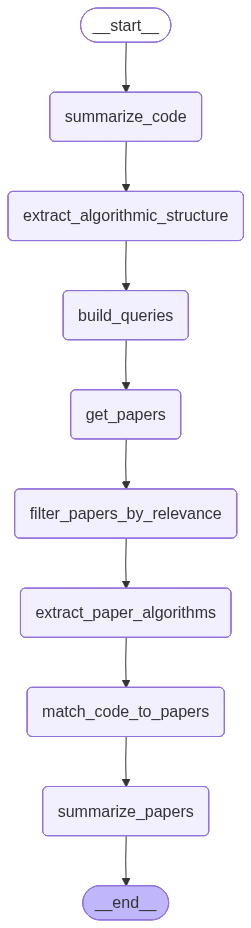

In [101]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("summarize_code", summarize_code)
graph_builder.add_node("extract_algorithmic_structure", extract_algorithmic_structure)
graph_builder.add_node("build_queries", build_queries)
graph_builder.add_node("get_papers", get_papers)
graph_builder.add_node("filter_papers_by_relevance", filter_papers_by_relevance)
graph_builder.add_node("extract_paper_algorithms", extract_paper_algorithms)
graph_builder.add_node("match_code_to_papers", match_code_to_papers)
graph_builder.add_node("summarize_papers", summarize_papers)

graph_builder.add_edge(START, "summarize_code")
graph_builder.add_edge("summarize_code", "extract_algorithmic_structure")
graph_builder.add_edge("extract_algorithmic_structure", "build_queries")
graph_builder.add_edge("build_queries", "get_papers")
graph_builder.add_edge("get_papers", "filter_papers_by_relevance")
graph_builder.add_edge("filter_papers_by_relevance", "extract_paper_algorithms")
graph_builder.add_edge("extract_paper_algorithms", "match_code_to_papers")
graph_builder.add_edge("match_code_to_papers", "summarize_papers")
graph_builder.add_edge("summarize_papers", END)

graph = graph_builder.compile()
graph

## Тесты агента

### Mock-примеры
Здесь приведены достаточно типичные куски кода, на которые модель должна однозначно сказать "исследовано здесь, новизны ноль"

In [102]:
example_code = '''
def compute_conductance(
    model,
    hook,
    x,
    x0,
    target_class,
    n_steps=64,
    fd_eps=1e-3,
    clear_every=8,
):
    """Estimate layer/neuron conductance along the baseline path using midpoint integration."""
    x = x.contiguous()
    x0 = x0.contiguous()
    delta_x = (x - x0).contiguous()

    def forward_with_layer(x_in):
        """Run a forward pass and return both model output and hooked layer activation."""
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    alphas = torch.linspace(0.0, 1.0, n_steps + 1, device=x.device, dtype=x.dtype)
    step = 1.0 / n_steps

    cond_accum = None
    used_fallback = False

    for k in range(n_steps):
        alpha = (alphas[k] + alphas[k + 1]) / 2.0
        x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

        out, act = forward_with_layer(x_alpha)
        _, logits = split_classifier_output(out)
        score = logits[0, target_class]

        # ∂F/∂y
        grad_y = torch.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]

        try:
            def act_only(inp):
                """Return only layer activations for Jacobian-vector product computation."""
                inp = inp.contiguous()
                _, a = forward_with_layer(inp)
                return a

            # dy/dα
            _, act_tangent = jvp(act_only, (x_alpha,), (delta_x,))

        except RuntimeError as e:
            if "view size is not compatible with input tensor's size and stride" not in str(e):
                raise

            used_fallback = True

            alpha_plus = min(float(alpha.item()) + fd_eps, 1.0)
            alpha_minus = max(float(alpha.item()) - fd_eps, 0.0)
            denom = alpha_plus - alpha_minus

            if denom == 0.0:
                raise RuntimeError("Не удалось построить finite-difference fallback для dy/dalpha.")

            with torch.no_grad():
                _, act_plus = forward_with_layer((x0 + alpha_plus * delta_x).contiguous())
                _, act_minus = forward_with_layer((x0 + alpha_minus * delta_x).contiguous())

            # dy/dα ≈ [y(α+ε) - y(α-ε)] / (2ε)
            act_tangent = (act_plus - act_minus) / denom
            del act_plus, act_minus

        integrand = grad_y * act_tangent
        cond_accum = integrand.detach() if cond_accum is None else (cond_accum + integrand.detach())

        del x_alpha, out, act, logits, score, grad_y, act_tangent, integrand
        hook.clear()

        if (k + 1) % clear_every == 0:
            clear_backend_cache()

    cond = cond_accum * step
    clear_backend_cache()

    if used_fallback:
        print("Предупреждение: jvp на текущем backend не сработал, для dy/dalpha использована конечная разность.")

    return cond.detach()
'''

result = graph.invoke({"code": example_code})
print(result["final_summary"])

summarize_code raw result:
 ```json
{
  "task": "Оценка проводимости слоя/нейрона вдоль пути от baseline",
  "method_kind": "Интегрирование методом средней точки с JVP и fallback на конечные разности",
  "keywords": [
    "conductance",
    "baseline path",
    "midpoint integration",
    "Jacobian-vector product",
    "JVP",
    "finite-difference",
    "hook",
    "activation",
    "gradient",
    "integrand",
    "neuron importance"
  ],
  "concepts": [
    "интерпретируемость моделей",
    "важность признаков",
    "анализ чувствительности",
    "интегральные методы",
    "path-based attribution"
  ],
  "method_markers": [
    "интегрирование по пути от baseline к входу",
    "использование JVP с fallback на конечные разности",
    "hook на промежуточный слой",
    "вычисление произведения градиента и тангенса",
    "очистка кэша для управления памятью"
  ],
  "search_hints": [
    "conductance neural networks",
    "baseline path integration",
    "Jacobian-vector product interpre

/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_39183/3470385213.py:142: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().isoformat(timespec="seconds") + "Z"


Source extraction for 'Path-based summary explanations for graph recommenders (extended version)':
  extraction_mode=tex_algorithm_block
  algorithm_found=True
  decision_reason=Algorithm environment found in TeX source.
Extracted direct algorithm for 'Path-based summary explanations for graph recommenders (extended version)'
Source type: tex_or_pdf_algorithm
Prompt source: \begin{algorithm}
\small
\caption{ST-based summary-explanations}
\label{al:steiner}
\begin{algorithmic}[1]
\Require Graph $G = (V, E, w)$, set of terminal nodes $T \subseteq V$
\Ensure Steiner Tree $S = (V_S, E_S)$

\State Initialize $V_S \leftarrow T$, $E_S \leftarrow \emptyset$
\State Compute shortest paths between all pairs of terminal nodes in $T$ using edge weights $w(e)$
\State Construct a complete graph $G_c = (T, E_c, w_c)$ where each edge $(u, v) \in E_c$ represents the shortest path distance between $u$ and $v$ in $G$
\ForAll{edges $(u, v) \in E_c$}
    \State $w_c(u, v) \leftarrow$ sum of edge weights alo

/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_39183/3470385213.py:142: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().isoformat(timespec="seconds") + "Z"


Source extraction for 'Memorization in Deep Neural Networks: Does the Loss Function matter?':
  extraction_mode=tex_method_section
  algorithm_found=False
  decision_reason=No explicit algorithm block found; using method section 'Role of loss function in resisting memorization'.
Selected papers for LLM algorithm extraction:
  score=4.50 | title=Path-Weighted Integrated Gradients for Interpretable Dementia Classification
  score=1.50 | title=Maximum Entropy Baseline for Integrated Gradients
  score=0.50 | title=Memorization in Deep Neural Networks: Does the Loss Function matter?
Selected for LLM fallback extraction: 'Maximum Entropy Baseline for Integrated Gradients'
Source type: llm_fallback_from_article_text
Prompt source: Integrated Gradients (IG) \cite{pmlr-v70-sundararajan17a} is one of the most widely used explainability methods at present, which illustrates the attribution of each pixel in the input $x$ to the corresponding prediction. IG is a gradient-based approach that address

...

extract_paper_algorithms raw result for 'Path-Weighted Integrated Gradients for Interpretable Dementia Classification':
 {
  "title": "Path-Weighted Integrated Gradients for Interpretable Dementia Classification",
  "paper_task": "Предложить и оценить метод Path-Weighted Integrated Gradients (PWIG) для улучшения интерпретируемости моделей глубокого обучения в задачах классификации деменции, предоставляя более тонкие, контекстно-зависимые и стабильные атрибуции по сравнению со стандартным Integrated Gradients.",
  "paper_research_question": "Можно ли расширить Integrated Gradients, введя весовую функцию вдоль пути интегрирования, чтобы получить более информативные, стабильные и клинически значимые объяснения для моделей классификации деменции, и как это влияет на способность выявлять биомаркеры?",
  "paper_method_kind": "gradient-based attribution method with path weighting",
  "paper_algorithm_signature": [
    "Выбрать базисный вход (baseline) и целевой вход (input).",
    "Определить

/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_39183/3470385213.py:142: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().isoformat(timespec="seconds") + "Z"


extract_paper_algorithms raw result for 'Memorization in Deep Neural Networks: Does the Loss Function matter?':
 ```json
{
  "title": "Memorization in Deep Neural Networks: Does the Loss Function matter?",
  "paper_task": "Эмпирическое исследование влияния функции потерь на склонность глубоких нейронных сетей к запоминанию (memorization) зашумленных данных.",
  "paper_research_question": "Может ли выбор функции потерь (CCE, MSE, RLL) повлиять на способность глубокой нейронной сети запоминать случайно измененные метки в обучающих данных?",
  "paper_method_kind": "Эмпирическое сравнение (experimental comparison)",
  "paper_algorithm_signature": [
    "Подготовка датасета: для каждого обучающего примера с вероятностью η заменить оригинальную метку на случайную из других классов.",
    "Обучение нейронной сети (Inception-Lite или ResNet) на подготовленных данных с использованием одной из трех функций потерь (CCE, MSE, RLL) и оптимизатора (SGD или Adam).",
    "На каждой эпохе вычислять две

/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_39183/3470385213.py:142: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().isoformat(timespec="seconds") + "Z"


rank_papers_for_matching raw result:
 ```json
[
  {
    "index": 1,
    "title": "Integrated Decision Gradients: Compute Your Attributions Where the Model Makes Its Decision",
    "relevance_score": 0.6,
    "keep_for_deep_match": true,
    "short_reason": "Использует path integration и градиенты по промежуточным признакам (логитам), но адаптивная выборка точек и фокус на логитах отличаются от фиксированного линейного пути и активаций слоя в коде."
  },
  {
    "index": 2,
    "title": "IG2: Integrated Gradient on Iterative Gradient Path for Feature Attribution",
    "relevance_score": 0.2,
    "keep_for_deep_match": false,
    "short_reason": "Построение итеративного градиентного пути, а не численное интегрирование вдоль линейного пути; отсутствует вычисление градиента score по активации слоя и JVP."
  },
  {
    "index": 3,
    "title": "Fast Axiomatic Attribution for Neural Networks",
    "relevance_score": 0.1,
    "keep_for_deep_match": false,
    "short_reason": "Теоретический ан

In [103]:
from IPython.display import display, Markdown

display(Markdown((result["final_summary"])))

### 1. Статьи, где это уже есть почти один в один
**Нет статей с полным совпадением.**  
Ни одна из найденных статей не описывает алгоритм, который бы точно соответствовал ключевым шагам кода:  
- **Оценка проводимости конкретного слоя/нейрона** через активации промежуточного слоя (с использованием хуков), а не градиенты по входу или логитам.  
- **Интегрирование методом средней точки** (midpoint rule) с фиксированным шагом по параметру α.  
- **Вычисление dy/dα через JVP** (Jacobian-vector product) с fallback на конечные разности.  
- **Явное управление памятью** (очистка кэша каждые N шагов).  

Ближайшие по структуре статьи (PWIG и IDG) используют интегрирование вдоль пути, но их ключевые механизмы (весовая функция, адаптивная выборка, фокус на логитах) отсутствуют в коде.

---

### 2. Частично релевантные статьи
#### **Path-Weighted Integrated Gradients (PWIG)**  
**Ссылка:** http://arxiv.org/abs/2509.17491v1  
**Совпадение:**  
- Линейный путь между baseline и входом с параметром α.  
- Дискретизация интервала [0,1] и агрегация градиентов вдоль пути.  
**Отличия:**  
- В PWIG ключевое нововведение — **весовая функция g(α)**, модулирующая вклад градиентов. В коде весов нет.  
- PWIG фокусируется на градиентах по входу, а код — на **активациях промежуточного слоя** (через хуки) и их производной по α.  
- В PWIG нет JVP/fallback или очистки кэша.  
**Вердикт:** Частичное совпадение по общей схеме path integration, но не по целевым объектам (активации слоя vs вход) и механике (веса vs фиксированный шаг).  

#### **Integrated Decision Gradients (IDG)**  
**Ссылка:** http://arxiv.org/abs/2305.20052v2  
**Совпадение:**  
- Интегрирование вдоль пути от baseline к входу.  
- Вычисление contribution как произведение градиентов (в IDG — по α и по логиту, в коде — градиент score по активации и dy/dα).  
**Отличия:**  
- IDG использует **адаптивную выборку точек** на основе изменений логита, код — фиксированный шаг.  
- IDG работает с **промежуточными логитами** (выходом модели), код — с **активациями произвольного слоя**.  
- В IDG нет JVP, хуков или управления памятью.  
**Вердикт:** Частичное совпадение по идее path-based attribution, но ключевые механизмы (адаптивность, логиты) не покрыты.

---

### 3. Фоновые, но полезные статьи
#### **IG2: Integrated Gradient on Iterative Gradient Path**  
**Ссылка:** http://arxiv.org/abs/2406.10852v1  
**Полезность:** Вводит итеративный градиентный путь (GradPath) и контрфактические базисы (GradCF). Показывает, что путь может строиться иначе, чем линейная интерполяция. Для кода — альтернативный взгляд на path construction, но не применим напрямую.  

#### **Fast Axiomatic Attribution for Neural Networks**  
**Ссылка:** http://arxiv.org/abs/2111.07668v1  
**Полезность:** Доказывает, что для однородных моделей (без bias) Integrated Gradients вычисляется за один проход. Код же использует JVP/fallback для произвольных моделей, что сложнее. Статья объясняет, почему в коде может потребоваться JVP (неоднородность архитектур).  

#### **Evaluating Feature Attribution Methods for Electrocardiogram**  
**Ссылка:** http://arxiv.org/abs/2211.12702v2  
**Полезность:** Показывает, что методы атрибуции нужно адаптировать под домен (ЭКГ). Код оценивает активации слоя — это может быть полезно для доменов, где важны промежуточные представления (например, медицинские изображения).  

#### **Maximum Entropy Baseline for Integrated Gradients**  
**Ссылка:** http://arxiv.org/abs/2204.05948v1  
**Полезность:** Дискуссия о выборе baseline. В коде baseline задаётся внешне, но статья помогает понять, как его можно оптимизировать для более надёжных атрибуций.  

**Остальные статьи** (Modern Mathematics of Deep Learning, Path-based summary explanations, Approximation of rough functions, Memorization in DNNs) — фоновые, не связаны напрямую с path-based attribution или работают в других доменах (графы, аппроксимация функций, memorization).

---

### 4. Что в коде выглядит потенциально новым или неочевидно покрытым
1. **Цель: оценка проводимости слоя/нейрона, а не всего входа.**  
   - Код явно извлекает активации **промежуточного слоя** через хуки и вычисляет градиент score класса по этим активациям (`grad_y = torch.autograd.grad(score, act, ...)`).  
   - В статьях (PWIG, IDG) акцент на градиентах по входу или логитам. Работа с активациями слоя как объектом атрибуции — менее распространена, ближе к "neuron importance" или "layer-wise relevance propagation", но с интегрированием вдоль пути.

2. **Механика dy/dα через JVP с fallback на конечные разности.**  
   - Код пытается вычислить производную активации по α (`dy/dα`) с помощью `jvp(act_only, (x_alpha,), (delta_x,))`. При ошибке — fallback на конечные разности (`(act_plus - act_minus) / denom`).  
   - В статьях dy/dα вычисляется аналитически (IDG) или не упоминается (PWIG использует градиент по входу). JVP как основной метод — редкость, обычно используют автоматическое дифференцирование по α. Fallback-механизм для устойчивости — инженерное решение, не описанное в литературе.

3. **Управление памятью через `clear_backend_cache()`.**  
   - Очистка кэша каждые `clear_every` шагов для предотвращения утечек памяти при длинных путях. Это практическая деталь, не обсуждаемая в статьях, но критичная для масштабируемости.

4. **Метод средней точки (midpoint rule) вместо адаптивной выборки.**  
   - Код использует фиксированную дискретизацию с вычислением в середине интервала (`x_alpha = baseline + alpha * (input - baseline)`).  
   - Статьи (IDG) предлагают адаптивную выборку на основе изменений выхода, PWIG — весовую функцию. Фиксированный midpoint — проще, но может быть менее эффективен в зонах насыщения.

5. **Комбинация: path integration + layer-specific attribution + JVP/fallback.**  
   - Ни одна статья не объединяет все три элемента:  
     (а) атрибуция **конкретного слоя** (не всего входа),  
     (б) **JVP для dy/dα** с fallback,  
     (в) **очистка кэша** для управления памятью.  
   - Ближайшее — PWIG (path integration + веса), но без JVP и хуков.

---

### Итоговый вердикт
**В коде присутствуют элементы, не покрытые найденными статьями почти один в один.**  
- **Общая основа** (интегрирование градиентов вдоль пути) пересекается с PWIG и IDG, но:  
  - Код фокусируется на **активациях слоя**, статьи — на градиентах по входу/логитам.  
  - В коде **нет адаптивной выборки** (IDG) и **весовой функции** (PWIG).  
  - В коде **есть JVP/fallback и управление памятью**, чего нет в статьях.  
- **Научная новизна** заключается в **специализации для оценки вклада промежуточных слоёв** с использованием JVP для эффективного вычисления производной по пути и инженерными приёмами для устойчивости. Это не просто вариация IG, а метод, ориентированный на "layer-wise conductance" в контексте path-based attribution.  

**Рекомендация:** Код можно позиционировать как **"Layer-wise Path Integration with JVP and Memory Management"**, что дополняет существующие методы (PWIG/IDG) за счёт:  
1. Работы с активациями любого слоя через хуки.  
2. Использования JVP для dy/dα (возможно, более эффективно, чем аналитическое дифференцирование по α).  
3. Практической устойчивости (fallback, очистка кэша).  

Для публикации стоит сравнить с PWIG/IDG на стандартных бенчмарках (например, insertion/deletion), показав, что фокус на слоях даёт преимущества в интерпретируемости для глубоких сетей.